# EMBEDDING EXPLORER — Feature Embeddings + Clustering
**MS Computer Vision Coding Project — Rochester Institute of Technology**

**(Poach) Phumapiwat Chanyutthagorn**

This notebook explores deep feature extraction using ResNet-50, performs unsupervised clustering, visualizes high-dimensional data, and implements an image retrieval system.

In [12]:
#!pip install umap-learn

In [5]:
# Optional: UMAP
try:
    import umap
    HAS_UMAP = True
    print("umap-learn has been installed")
except ImportError:
    HAS_UMAP = False
    print("[WARNING] umap-learn not installed. Install with: !pip install umap-learn")

umap-learn has been installed


In [3]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from scipy.optimize import linear_sum_assignment

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
NUM_CLASSES = 10
CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
N_SAMPLES = 10000 
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device: {DEVICE}")

Device: cpu


## Part 0: Data Loading
Loading CIFAR-10 with two different transforms:
1. **ResNet Transform**: Resized to 224x224 and normalized for the model.
2. **Display Transform**: Original 32x32 for visualization.

In [7]:
transform_resnet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_display = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_resnet)
train_dataset_display = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_display)

indices = np.random.choice(len(train_dataset), N_SAMPLES, replace=False)
train_subset = Subset(train_dataset, indices)
display_subset = Subset(train_dataset_display, indices)
all_labels = np.array([train_dataset.targets[i] for i in indices])

print(f"Loaded {len(train_subset)} images.")

Loaded 10000 images.


## Part 1: Feature Extraction
Using a pre-trained ResNet-50 and attach "hooks" to extract features from intermediate layers (`layer2`, `layer3`, `layer4`) and the final `avgpool` layer.

In [8]:
def extract_features_multilayer(model, dataset, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    activations = {}
    
    def get_hook(name):
        def hook(module, input, output):
            if output.dim() == 4:
                activations[name] = output.mean(dim=[2, 3])
            else:
                activations[name] = output.squeeze()
        return hook
    
    hooks = [
        model.layer2.register_forward_hook(get_hook("layer2")),
        model.layer3.register_forward_hook(get_hook("layer3")),
        model.layer4.register_forward_hook(get_hook("layer4")),
        model.avgpool.register_forward_hook(get_hook("avgpool"))
    ]
    
    features = defaultdict(list)
    model.eval()
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            images = images.to(DEVICE)
            _ = model(images)
            for name in activations:
                features[name].append(activations[name].cpu().numpy())
    
    for h in hooks: h.remove()
    return {name: np.concatenate(feats, axis=0) for name, feats in features.items()}

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(DEVICE)
all_features = extract_features_multilayer(resnet, train_subset)
embeddings = all_features["avgpool"]
embeddings_normed = normalize(embeddings)

## Part 2: Clustering and Metrics
Using K-Means to group the images into 10 clusters and evaluate them against ground-truth labels using Purity and NMI.

In [9]:
def cluster_purity(labels_true, labels_pred):
    cm = confusion_matrix(labels_true, labels_pred)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)

def hungarian_accuracy(labels_true, labels_pred):
    cm = confusion_matrix(labels_true, labels_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    return cm[row_ind, col_ind].sum() / cm.sum(), dict(zip(col_ind, row_ind))

kmeans = KMeans(n_clusters=NUM_CLASSES, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_normed)

purity = cluster_purity(all_labels, cluster_labels)
nmi = normalized_mutual_info_score(all_labels, cluster_labels)
acc, cluster_to_class = hungarian_accuracy(all_labels, cluster_labels)

print(f"Purity: {purity:.4f} | NMI: {nmi:.4f} | Hungarian Acc: {acc:.4f}")

Purity: 0.7431 | NMI: 0.6025 | Hungarian Acc: 0.7431


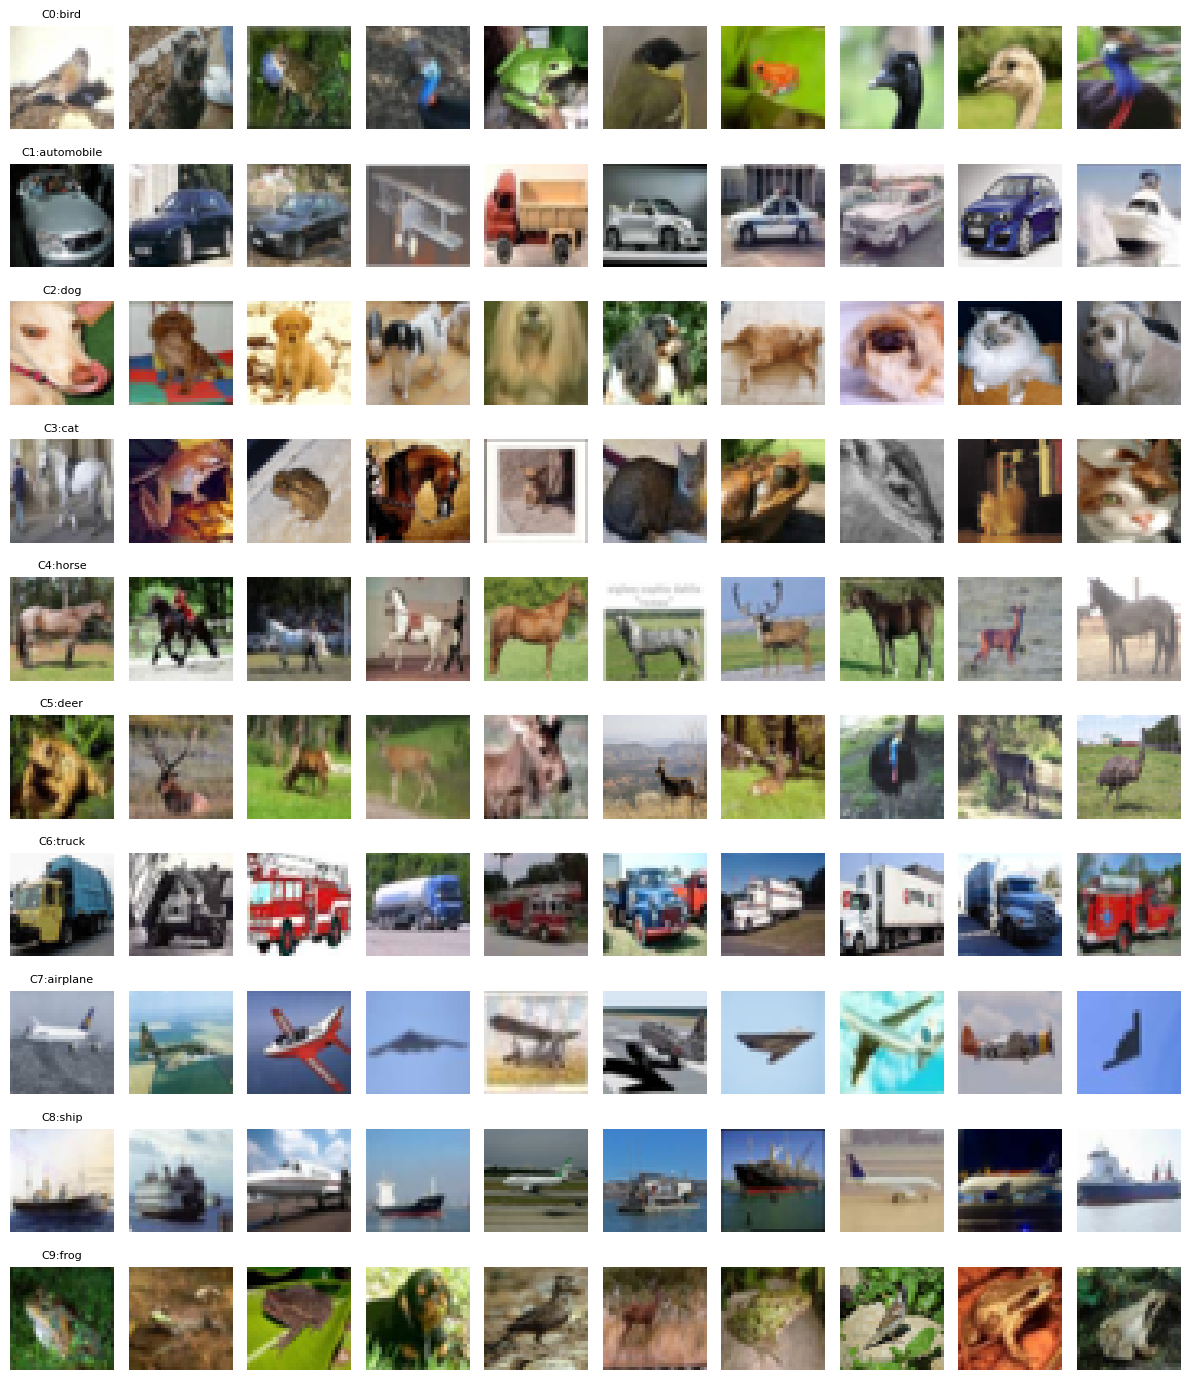

In [10]:
def make_contact_sheet(cluster_labels, display_dataset, cluster_to_class):
    fig, axes = plt.subplots(10, 10, figsize=(12, 14))
    for cluster_id in range(10):
        mask = cluster_labels == cluster_id
        cluster_indices = np.where(mask)[0][:10]
        class_name = CIFAR10_CLASSES[cluster_to_class.get(cluster_id, 0)]
        for j in range(10):
            ax = axes[cluster_id, j]
            ax.axis("off")
            if j < len(cluster_indices):
                img, _ = display_dataset[cluster_indices[j]]
                ax.imshow(img.permute(1, 2, 0).numpy())
            if j == 0: ax.set_title(f"C{cluster_id}:{class_name}", fontsize=8)
    plt.tight_layout()
    plt.show()

make_contact_sheet(cluster_labels, display_subset, cluster_to_class)

## Part 3: t-SNE & UMAP
Reducing the 2048-dimensional embeddings to 2D to visualize the class separation.

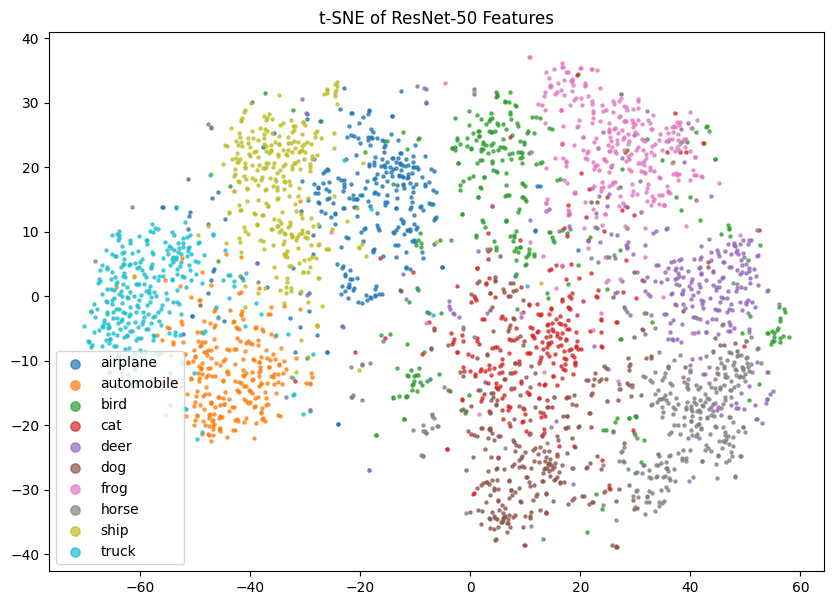

In [11]:
# t-SNE Plotting

VIS_SAMPLES = 3000
vis_idx = np.random.choice(N_SAMPLES, VIS_SAMPLES, replace=False)
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
coords = tsne.fit_transform(embeddings_normed[vis_idx])

plt.figure(figsize=(10, 7))
for c in range(NUM_CLASSES):
    m = all_labels[vis_idx] == c
    plt.scatter(coords[m, 0], coords[m, 1], label=CIFAR10_CLASSES[c], s=5, alpha=0.7)
plt.legend(markerscale=3)
plt.title("t-SNE of ResNet-50 Features")
plt.show()

Running UMAP on 3000 samples...


C:\Users\User\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


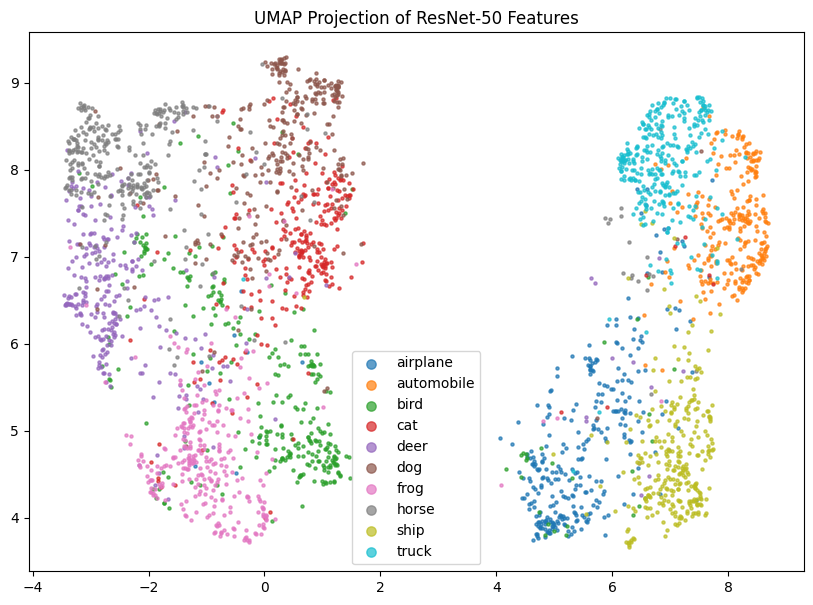

In [16]:
print(f"Running UMAP on {VIS_SAMPLES} samples...")

# UMAP is generally much faster than t-SNE for large datasets
reducer = umap.UMAP(n_neighbors=15, 
                    min_dist=0.1, 
                    n_components=2, 
                    metric='cosine', 
                    random_state=SEED)
    
coords_umap = reducer.fit_transform(embeddings_normed[vis_idx])

plt.figure(figsize=(10, 7))
for c in range(NUM_CLASSES):
    mask = all_labels[vis_idx] == c
    plt.scatter(coords_umap[mask, 0], coords_umap[mask, 1], 
                label=CIFAR10_CLASSES[c], s=5, alpha=0.7)
    
plt.legend(markerscale=3, loc='best')
plt.title("UMAP Projection of ResNet-50 Features")
plt.show()

## Part 4: Image Retrieval
Given an image, can we find the most similar images in the dataset? We use `NearestNeighbors` with cosine similarity.

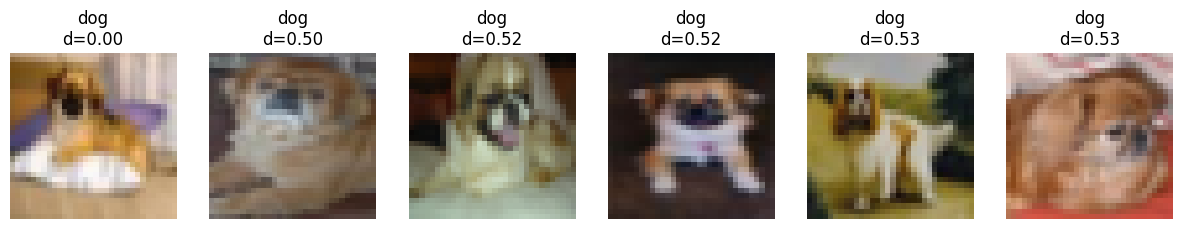

In [13]:
# Code (Retrieval System)

nn_index = NearestNeighbors(n_neighbors=6, metric="euclidean")
nn_index.fit(embeddings_normed)

def show_retrieval(query_idx):
    dist, indices = nn_index.kneighbors(embeddings_normed[query_idx:query_idx+1])
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i, idx in enumerate(indices[0]):
        img, _ = display_subset[idx]
        axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].set_title(f"{CIFAR10_CLASSES[all_labels[idx]]}\nd={dist[0][i]:.2f}")
        axes[i].axis("off")
    plt.show()

show_retrieval(random.randint(0, N_SAMPLES))

## Part 5: Supervised Fine-Tuning (Stretch)

Training a small linear head on 10% of the features to see how much the embedding space improves when supervised.

In [14]:
# Code (Fine Tuning)

class LinearHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2048, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

# Training on a small slice
n_train = int(0.1 * N_SAMPLES)
X_train = torch.FloatTensor(embeddings[:n_train]).to(DEVICE)
y_train = torch.LongTensor(all_labels[:n_train]).to(DEVICE)

model_head = LinearHead().to(DEVICE)
optimizer = optim.Adam(model_head.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(50):
    logits = model_head(X_train)
    loss = criterion(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

print("Fine-tuning complete.")

Epoch 0, Loss: 2.3215
Epoch 10, Loss: 0.5926
Epoch 20, Loss: 0.3313
Epoch 30, Loss: 0.2106
Epoch 40, Loss: 0.1455
Fine-tuning complete.


In [24]:
# --- ANALYZING THE IMPROVEMENT From Fine Tunning ---

# 1. Extract the "Fine tuned" embeddings from the penultimate layer of your new head
model_head.eval()
with torch.no_grad():
    # Pass all original avgpool embeddings through the first layer of the head
    # to get the new 256-D specialized features
    specialized_features = model_head.net[0](torch.FloatTensor(embeddings).to(DEVICE))
    specialized_features = torch.relu(specialized_features).cpu().numpy()

specialized_normed = normalize(specialized_features)

# 2. Re-run K-Means on these new features
km_fine = KMeans(n_clusters=10, random_state=SEED, n_init=10)
labels_fine = km_fine.fit_predict(specialized_normed)

# 3. Calculate new metrics
purity_fine = cluster_purity(all_labels, labels_fine)
nmi_fine = normalized_mutual_info_score(all_labels, labels_fine)
acc_fine, _ = hungarian_accuracy(all_labels, labels_fine)

print("\n--- COMPARISON: FROZEN VS. FINE TUNED ---\n")

print(f"Metric        | Frozen (Part 2) | Fine-Tuned (Part 5) | Improvement")
print(f"Purity        | {purity:.4f}          | {purity_fine:.4f}              | {purity_fine-purity:+.4f}")
print(f"NMI           | {nmi:.4f}          | {nmi_fine:.4f}              | {nmi_fine-nmi:+.4f}")
print(f"Hungarian Acc | {acc:.4f}          | {acc_fine:.4f}              | {acc_fine-acc:+.4f}")


--- COMPARISON: FROZEN VS. FINE-TUNED ---

Metric        | Frozen (Part 2) | Fine-Tuned (Part 5) | Improvement
Purity        | 0.7431          | 0.8493              | +0.1062
NMI           | 0.6025          | 0.7246              | +0.1222
Hungarian Acc | 0.7431          | 0.8493              | +0.1062
